In [2]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import expon, skew, norm,gamma, anderson,goodness_of_fit, monte_carlo_test, probplot, skewnorm
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

from statsmodels.sandbox.distributions.gof_new import kstest

plt.rcParams['figure.figsize'] = [15, 7]
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

In [3]:
mainDataFrame = np.array([])
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}') # import the attribute-relation file format
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c': # checks if the file is a synthetic dataset
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n,p=1)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, distanceMetric='max'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if distanceMetric == 'median':
            arr += [np.median(x)]
        elif distanceMetric == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif distanceMetric == 'max':
            arr += [np.max(x)]
        elif distanceMetric == 'minMax':
            arr += [np.max(x) + x[1]]
        elif distanceMetric == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif distanceMetric == 'min':
            arr += [x[1]]

    return arr


def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # returns index and distance of points
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, distanceMetric="max") # return arr of max values
        Q3 = np.quantile(arr,.75)
        IQR = Q3 - np.quantile(arr,.25)
        posNeg4 = []
        spaceStep4 = np.linspace(-1.5,1.5,30) # threshold from 0 to .99, 30 samples
        for e in spaceStep4:
            upperBound = Q3 + e*IQR
            newArr = arr > upperBound
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())]) # True positive rate, false positive rate

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)] # return the area under the curve

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array
    global mainDataFrame
    mainDataFrame = np.append(mainDataFrame,sortIndex(arr))

def qqPlots(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="max")
    params = gamma.fit(arr)
    print(f"a: {params[0]} Loc: {params[1]}, Scale: {params[2]}")
    print(skew(arr),np.var(arr))
    fig, ax = plt.subplots(2,1)
    results = probplot(arr,dist=stats.gamma, plot=ax[0],sparams=(params[0],params[1],params[2]),rvalue=True)
    fig.suptitle(name)
    dista = plt.hist(arr,bins=int(np.sqrt(len(arr))),density=True)
    sns.kdeplot(arr,bw=.3)
    plt.xlabel("Maximum Manhattan Distance")
    plt.ylabel("Density")
    plt.show()
    
def boxplot_draw(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, distanceMetric="max")
    sns.boxplot(arr)
    plt.show()
    

def sortIndex(arrV):
    indexArr = []
    for a in range(len(arrV)):
        indexArr += [[arrV[a],a+2]]
    indexArr = np.array(indexArr)
    return indexArr[indexArr[:,0].argsort()[::-1]][:3]

0.7556700620722586 20 [0.7261857392965144, 0.7461901161865352, 0.7388190354925991, 0.7375954957822697, 0.745832007003024, 0.7392666719719878, 0.7381625019894955, 0.7463890657329301, 0.7382022918987745, 0.7407687410472704, 0.7428079738978196, 0.7441707782906255, 0.7488958300175076, 0.7476424478752188, 0.7473042336463472, 0.748438246060799, 0.7537501989495464, 0.7539292535413019, 0.7556700620722586, 0.7505968486391851, 0.7477419226484163, 0.7494827311793728, 0.7486272481298741, 0.7498408403628839, 0.750119369727837, 0.7475827630113003, 0.7485476683113162, 0.7524371319433392, 0.7525962915804552, 0.7498109979309246, 0.7517507560082762, 0.7520790227598281, 0.7528947159000476, 0.7523376571701416, 0.7551527932516314, 0.7527355562629318, 0.750039789909279, 0.7508753780041382, 0.7494429412700938, 0.7502088970237147, 0.7503282667515517, 0.7470257042813943, 0.7525067642845774, 0.7509649053000159, 0.7512434346649689, 0.750079579818558, 0.7482890339010027, 0.748517825879357, 0.7474037084195448, 0.7

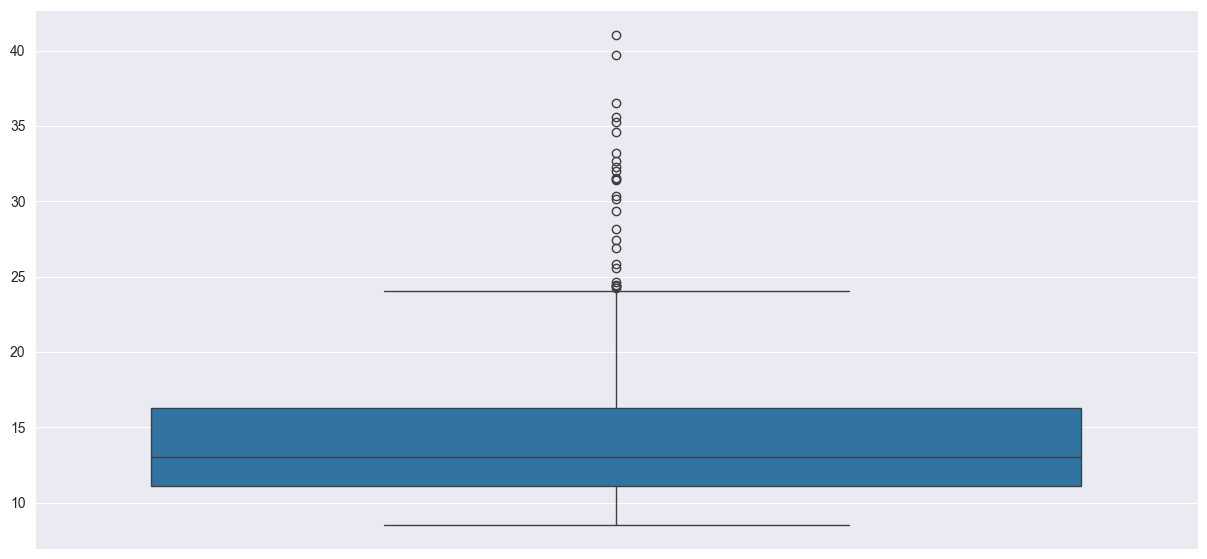

In [4]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
boxplot_draw(X,y,20)
#qqPlots(X,y,41,"Arrhythmia Normalized, without duplicates (46% of Outliers)")

In [5]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)

0.6311649659863946 7 [0.5214710884353742, 0.5666808390022675, 0.5890022675736961, 0.5673185941043084, 0.593891723356009, 0.6311649659863946, 0.6046626984126984, 0.5708616780045352, 0.5734835600907029, 0.5620039682539683, 0.5847505668934241, 0.540249433106576, 0.5449971655328798, 0.5498866213151927, 0.5450680272108843, 0.5150226757369614, 0.4983701814058956, 0.5218253968253969, 0.516156462585034, 0.49234693877551017, 0.4886621315192744, 0.5113378684807256, 0.5158021541950113, 0.508078231292517, 0.5034013605442176, 0.4983701814058957, 0.5015589569160998, 0.4986536281179138, 0.4931972789115646, 0.4916383219954648, 0.4900793650793651, 0.48809523809523814, 0.4931264172335601, 0.4947562358276644, 0.4937641723356009, 0.4925595238095238, 0.48717403628117917, 0.4848356009070295, 0.4871031746031746, 0.4842687074829931, 0.48313492063492064, 0.44075963718820865, 0.47130102040816324, 0.4701672335600907, 0.4306972789115647, 0.4545068027210884, 0.4944727891156463, 0.48823696145124723, 0.5052437641723

In [6]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)

0.8198846153846154 6 [0.3118846153846154, 0.43026923076923085, 0.6008846153846154, 0.8127307692307691, 0.8198846153846154, 0.8059615384615385, 0.8010769230769232, 0.7885, 0.7978076923076923, 0.7822692307692308, 0.773846153846154, 0.7758461538461541, 0.7683076923076926, 0.7669615384615386, 0.7686153846153847, 0.7700384615384617, 0.7630384615384617, 0.7473076923076925, 0.7448461538461539, 0.754346153846154, 0.757346153846154, 0.7562307692307694, 0.7540769230769233, 0.7487307692307694, 0.7485384615384617, 0.7370000000000001, 0.7401153846153846, 0.7355769230769231, 0.7388076923076924, 0.7348846153846155, 0.7326923076923079, 0.728769230769231, 0.7321153846153848, 0.7286923076923079, 0.7313846153846154, 0.7319999999999999, 0.7297307692307692, 0.7306538461538463, 0.7299230769230769, 0.7285769230769232, 0.7250384615384616, 0.7234615384615386, 0.7229615384615385, 0.7235, 0.721923076923077, 0.7205384615384616, 0.708923076923077, 0.7092692307692308, 0.7046923076923077, 0.7103846153846154, 0.70592

In [7]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)

0.9295774647887325 3 [0.8920187793427229, 0.9295774647887325, 0.6431924882629108, 0.9295774647887324, 0.9201877934272299, 0.9201877934272301, 0.92018779342723, 0.915492957746479, 0.915492957746479, 0.9154929577464788, 0.9107981220657277, 0.9061032863849764, 0.9248826291079812, 0.9248826291079812, 0.9248826291079812, 0.9248826291079812, 0.92018779342723, 0.92018779342723, 0.9201877934272301, 0.9154929577464789, 0.9154929577464789, 0.9107981220657277, 0.9107981220657277, 0.9107981220657276, 0.9107981220657276, 0.9107981220657276, 0.9107981220657276, 0.9107981220657276, 0.8826291079812206, 0.8873239436619718, 0.8873239436619716, 0.9014084507042252, 0.92018779342723, 0.92018779342723, 0.9248826291079811, 0.9154929577464788, 0.915492957746479, 0.9154929577464788, 0.9154929577464788, 0.9107981220657277, 0.9107981220657277, 0.9107981220657276, 0.9107981220657279, 0.9107981220657277, 0.9107981220657276, 0.9107981220657276, 0.9061032863849764, 0.9014084507042253, 0.9014084507042253, 0.901408450

In [8]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)

KeyboardInterrupt: 

In [22]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.5297308721995209 12 [0.4419473016767649, 0.4459630829928139, 0.4914752712413696, 0.49866140622798377, 0.5101451317458081, 0.5215584049598423, 0.5147949837959701, 0.5194448358461321, 0.5171199098210512, 0.5206425250105678, 0.5297308721995209, 0.5194448358461323, 0.5256446385796815, 0.5220515710863746, 0.5210652388333099, 0.5262787093137947, 0.5255741862758913, 0.5266309708327462, 0.5247992109341975, 0.5245878540228266, 0.5254332816683105, 0.5210652388333099, 0.5195857404537129, 0.521276595744681, 0.5219106664787939, 0.524446949415246, 0.5200789065802454, 0.5113428209102437, 0.5106382978723405, 0.5132450331125827, 0.5073974918979852, 0.5059179935183882, 0.49443426800056356, 0.49189798506411153, 0.4914752712413695, 0.49210934197548256, 0.4774552627870931, 0.4907707482034662, 0.5059179935183883, 0.5044384951387911, 0.48386642243201355, 0.495350147949838, 0.4864027053684655, 0.4912639143299986, 0.49020712977314357, 0.4873890376215303, 0.4886571790897562, 0.48386642243201344, 0.47893476116

In [23]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.6578611111111111 68 [0.5721944444444444, 0.5802777777777778, 0.5916111111111111, 0.5733055555555555, 0.5800555555555554, 0.5802777777777778, 0.5638333333333333, 0.566111111111111, 0.591111111111111, 0.5853888888888888, 0.5874444444444444, 0.581, 0.6013055555555556, 0.6024444444444443, 0.6273888888888889, 0.6085, 0.6071944444444445, 0.6138888888888888, 0.6036666666666667, 0.6054444444444443, 0.6101944444444445, 0.6098888888888888, 0.6221111111111112, 0.5935, 0.5653055555555555, 0.5814444444444444, 0.5847777777777777, 0.5648333333333333, 0.5727777777777777, 0.5606944444444445, 0.5658611111111111, 0.5771944444444446, 0.5581111111111112, 0.5769444444444445, 0.5800277777777779, 0.5740277777777778, 0.5806111111111112, 0.5939722222222223, 0.5893333333333334, 0.6065555555555555, 0.6237222222222223, 0.607611111111111, 0.595388888888889, 0.6055833333333334, 0.5856944444444445, 0.6171944444444444, 0.6141388888888888, 0.6023888888888889, 0.6102222222222222, 0.6060277777777778, 0.5993888888888889

In [24]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.862059620596206 17 [0.810840108401084, 0.8032520325203253, 0.8260162601626018, 0.8186991869918699, 0.8349593495934958, 0.8409214092140921, 0.8439024390243903, 0.8487804878048781, 0.8490514905149051, 0.8536585365853658, 0.856639566395664, 0.8504065040650406, 0.8563685636856369, 0.8523035230352303, 0.856910569105691, 0.862059620596206, 0.8620596205962059, 0.8604336043360435, 0.856910569105691, 0.8601626016260162, 0.8550135501355014, 0.8317073170731708, 0.8140921409214094, 0.8016260162601627, 0.8032520325203253, 0.7953929539295393, 0.7859078590785908, 0.786178861788618, 0.7902439024390244, 0.7894308943089432, 0.7907859078590788, 0.7864498644986451, 0.7867208672086721, 0.783739837398374, 0.7745257452574525, 0.7785907859078591, 0.7785907859078591, 0.7823848238482387, 0.7788617886178862, 0.7897018970189702, 0.7913279132791329, 0.7907859078590787, 0.7875338753387535, 0.7815718157181573, 0.7775067750677509, 0.7747967479674798, 0.7821138211382115, 0.7799457994579947, 0.7829268292682927, 0.781

In [25]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.7841561423650976 26 [0.6268656716417911, 0.4506314580941446, 0.5332950631458093, 0.5539609644087256, 0.5114810562571757, 0.513203214695752, 0.5401836969001148, 0.555683122847302, 0.5551090700344432, 0.5591274397244546, 0.560849598163031, 0.5792192881745121, 0.5861079219288174, 0.6216991963260621, 0.6417910447761194, 0.6452353616532722, 0.695752009184845, 0.6911595866819749, 0.6980482204362802, 0.7560275545350172, 0.7485648679678529, 0.7738231917336394, 0.7548794489092996, 0.7795637198622273, 0.7841561423650976, 0.78300803673938, 0.7761194029850746, 0.7715269804822045, 0.7732491389207807, 0.7761194029850746, 0.7743972445464983, 0.7789896670493686, 0.7766934557979334, 0.7772675086107922, 0.774971297359357, 0.7629161882893225, 0.7721010332950632, 0.7715269804822044, 0.7680826636050517, 0.7721010332950632, 0.7721010332950631, 0.7629161882893227, 0.7393800229621125, 0.6343283582089552, 0.6389207807118255, 0.6521239954075776, 0.6096440872560276, 0.5975889781859932, 0.624569460390356, 0.638

In [26]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.7309888059701493 68 [0.6350410447761194, 0.657910447761194, 0.6835186567164179, 0.6864664179104477, 0.6889179104477613, 0.7006679104477612, 0.698705223880597, 0.7010410447761194, 0.7118619402985075, 0.712007462686567, 0.7127350746268656, 0.7182238805970149, 0.711839552238806, 0.7129253731343282, 0.7180447761194031, 0.7144925373134328, 0.7216380597014925, 0.7178992537313433, 0.719141791044776, 0.7224216417910448, 0.7220037313432834, 0.7228694029850747, 0.721082089552239, 0.7199179104477612, 0.7189440298507461, 0.7175223880597014, 0.7204253731343284, 0.7218843283582088, 0.7192985074626865, 0.7234440298507461, 0.7213582089552237, 0.7237238805970149, 0.7247388059701494, 0.722179104477612, 0.7213544776119402, 0.7207574626865672, 0.719141791044776, 0.7203208955223879, 0.7210970149253733, 0.7211119402985073, 0.7210410447761194, 0.7204067164179105, 0.7209776119402984, 0.7220597014925373, 0.7217276119402986, 0.7224402985074628, 0.7236156716417911, 0.7237014925373134, 0.7240223880597015, 0.723

In [27]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)

0.9661377944760358 57 [0.8801330219333876, 0.9305036555645816, 0.9372943744922827, 0.935458976441917, 0.9436992282696994, 0.9478066612510155, 0.9460804224207962, 0.9483143785540211, 0.9502437043054428, 0.9528787571080423, 0.9494313566206335, 0.9506346466287572, 0.9537824939073923, 0.954726848090983, 0.9580498578391551, 0.9549248578391552, 0.9562474614134852, 0.9584128757108041, 0.9603091998375305, 0.9591135255889521, 0.9607280666125102, 0.9616216490658002, 0.959986799350122, 0.9585524979691309, 0.960271121039805, 0.9619491267262388, 0.9605148253452478, 0.9635484362307067, 0.9625126929325749, 0.9618069658813971, 0.962873172217709, 0.9617739642567019, 0.9632336515028432, 0.9624669983753047, 0.9635763606823721, 0.962576157595451, 0.9640510763606822, 0.9636550568643379, 0.9638022948822096, 0.9632057270511779, 0.9628147847278635, 0.9615074126726239, 0.9630864134849716, 0.9625380787977253, 0.9641932372055241, 0.9634418155970754, 0.9631701868399674, 0.9639926888708367, 0.9634621242891959, 0.9

In [28]:
mainDataFrame = mainDataFrame.reshape((-1, 2))
dfNew = pd.DataFrame(mainDataFrame, columns=['ROC AUC', 'K'])
dfNew.head(10)
dfNew.to_csv('Final_Data_BoxPlot.csv', index=False)